In [ ]:
# mysql과 python 연동하기

import koreanize_matplotlib
import pymysql
import pandas as pd

conn = pymysql.connect(host='172.30.1.12', user='team1', password='1234', database='team1_01', charset='utf8')

cur = conn.cursor()


# 시도, 사고 수 평균, 전세율 평균
query = """
SELECT
    dc.sido, avg(jda.count) AS count_avg, avg(pr.value) AS price_rate_avg
FROM
    jeonse_deposit_accidents jda
INNER JOIN price_rate pr
ON jda.legal_dong_code = pr.NO
INNER JOIN dong_code dc
ON pr.NO = dc.legal_dong_code
GROUP BY jda.legal_dong_code
ORDER BY dc.LEGAL_DONG_CODE 
;
"""

cur.execute(query)
rows = cur.fetchall()
print(rows)

language_df = pd.DataFrame(rows)
print(language_df)

cur.close()
conn.close()

(('서울특별시', Decimal('835.9507'), 61.832167832145096), ('부산광역시', Decimal('212.7495'), 66.66503496504932), ('대구광역시', Decimal('92.9883'), 67.8377622377533), ('인천광역시', Decimal('385.5030'), 64.86013986013442), ('광주광역시', Decimal('54.5521'), 65.84615384615743), ('대전광역시', Decimal('59.5285'), 72.14475524475378), ('울산광역시', Decimal('52.7132'), 66.94265734265959), ('세종특별자치시', Decimal('53.0599'), 67.50419580420179), ('경기도', Decimal('1023.6648'), 49.61748251748159), ('충청북도', Decimal('66.1610'), 64.84195804196521), ('충청남도', Decimal('82.1586'), 63.49440559442626), ('전라남도', Decimal('39.0000'), 62.381118881130334), ('경상북도', Decimal('92.3212'), 62.07132867131771), ('경상남도', Decimal('129.9305'), 63.77202797202541), ('제주특별자치도', Decimal('17.2060'), 61.047552447548135))
          0          1          2
0     서울특별시   835.9507  61.832168
1     부산광역시   212.7495  66.665035
2     대구광역시    92.9883  67.837762
3     인천광역시   385.5030  64.860140
4     광주광역시    54.5521  65.846154
5     대전광역시    59.5285  72.144755
6     

C:\Users\KDS24\AppData\Local\Temp\ipykernel_12152\924150623.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(language_df['지역'], rotation=45)


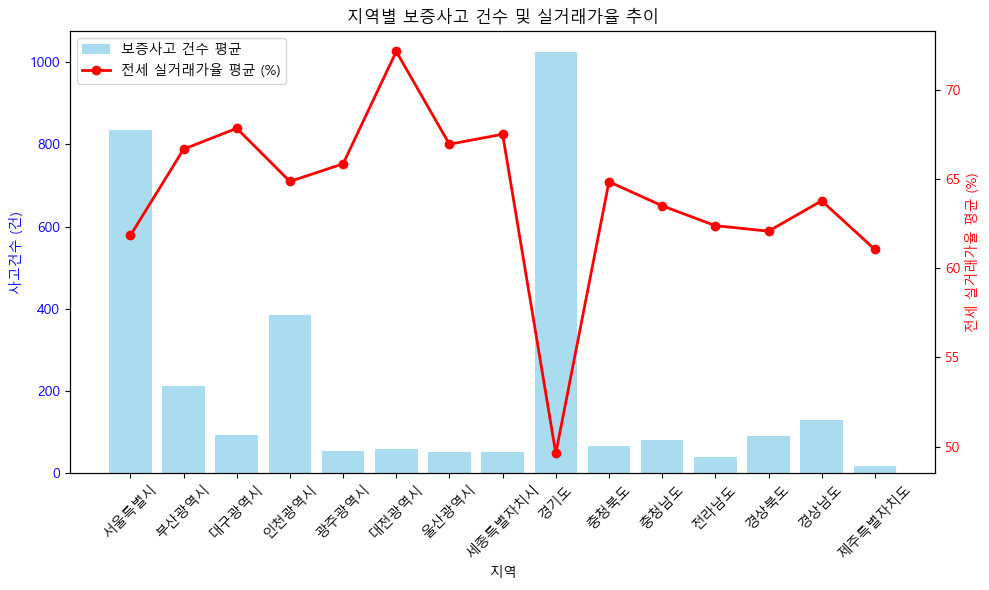

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

# 컬럼 이름 지정
language_df.columns = ['지역', '보증사고 건수 평균', '전세 실거래가율 평균']

# 한글 폰트 설정 (Windows 기준, Mac은 'AppleGothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 사고건수 컬럼을 float 타입으로 변경
#language_df['보증사고 건수 평균'] = language_df['보증사고 건수 평균'].astype(float)
#
## 그 다음 조 단위로 나누기
#language_df['보증사고 건수 평균'] = language_df['보증사고 건수 평균'] / 1e12

# 2. 그래프 생성
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- 막대 그래프 (보증사고) ---
ax1.bar(language_df['지역'], language_df['보증사고 건수 평균'], color='skyblue', label='보증사고 건수 평균', alpha=0.7)
ax1.set_xlabel('지역')
ax1.set_xticklabels(language_df['지역'], rotation=45)
ax1.set_ylabel('사고건수 (건)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# --- 이중 축 생성 (실거래가율) ---
ax2 = ax1.twinx() 
ax2.plot(language_df['지역'], language_df['전세 실거래가율 평균'], color='red', marker='o', linewidth=2, label='전세 실거래가율 평균 (%)')
ax2.set_ylabel('전세 실거래가율 평균 (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

# 3. 마무리 (제목 및 레이아웃)
plt.title('지역별 보증사고 건수 및 실거래가율 추이')
fig.tight_layout()
plt.show()

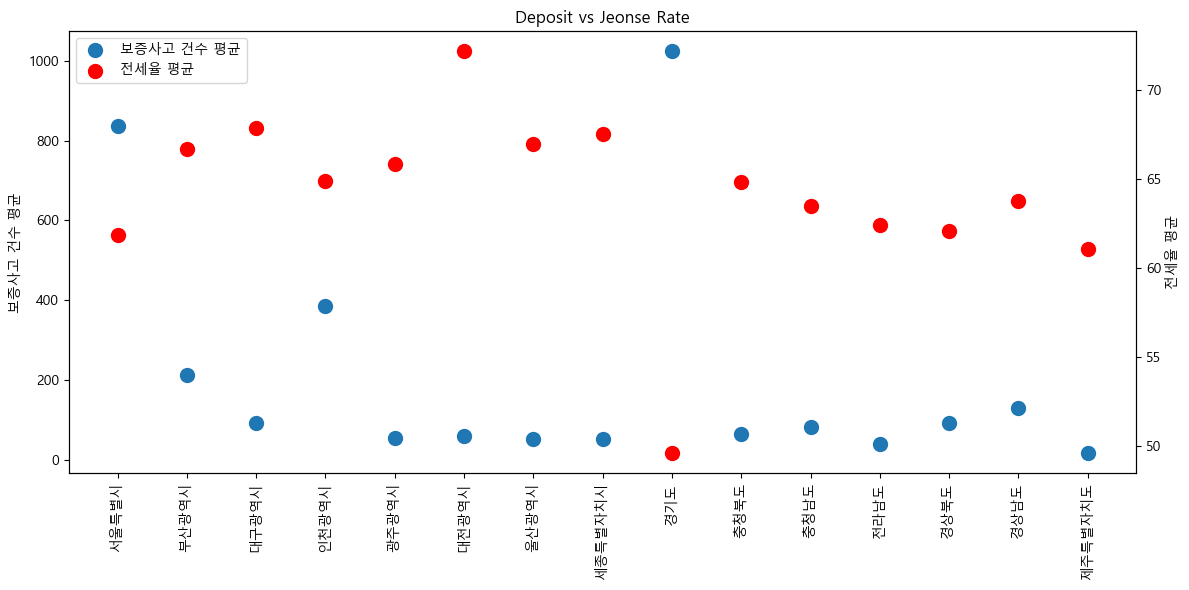

In [40]:
import matplotlib.pyplot as plt

# 컬럼 이름 지정
language_df.columns = ['region', '보증사고 건수 평균', '전세율 평균']


fig, ax1 = plt.subplots(figsize=(12,6))

x = range(len(language_df))

# 보증금
sc1 = ax1.scatter(x, language_df['보증사고 건수 평균'],
                  label='보증사고 건수 평균', s=100)
ax1.set_ylabel("보증사고 건수 평균")

# 전세율
ax2 = ax1.twinx()
sc2 = ax2.scatter(x, language_df['전세율 평균'],
                  color='red', label='전세율 평균', s=100)
ax2.set_ylabel("전세율 평균")

ax1.set_xticks(x)
ax1.set_xticklabels(language_df['region'], rotation=90)

# ⭐ legend 합치기
handles = [sc1, sc2]
labels = [h.get_label() for h in handles]
ax1.legend(handles, labels, loc='upper left')

plt.title("Deposit vs Jeonse Rate")
plt.tight_layout()
plt.show()

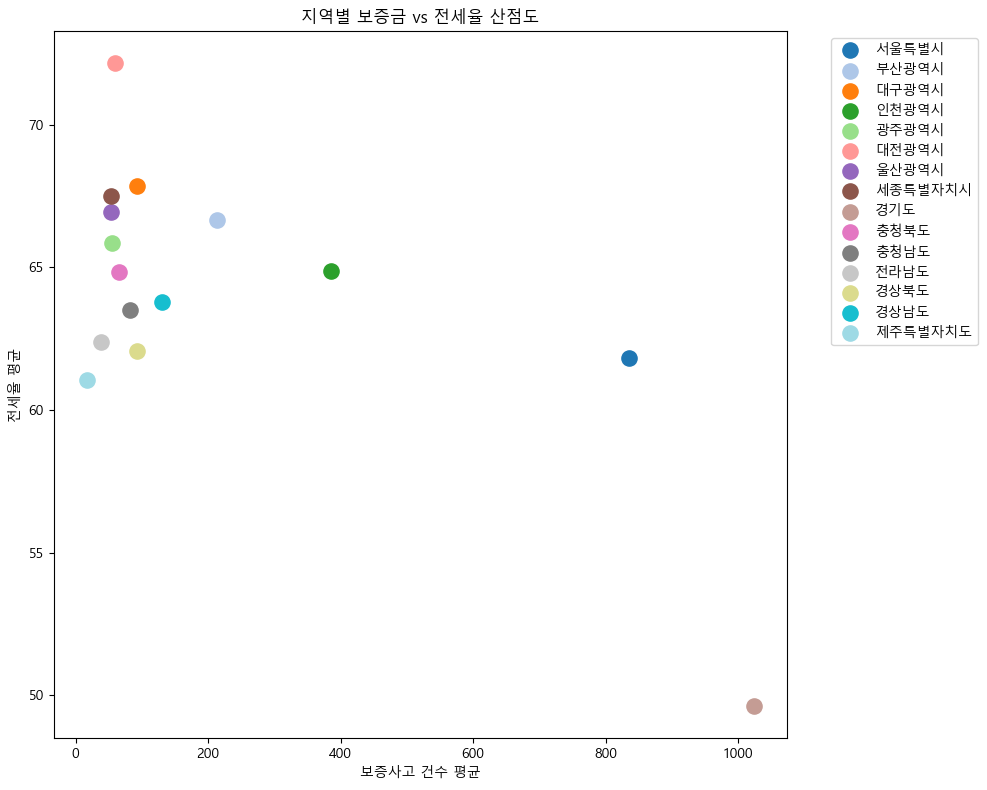

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# 컬럼 이름 정리
language_df.columns = ['region', '보증사고 건수 평균', '전세율 평균']

plt.figure(figsize=(10,8))

# 색상 자동 생성
colors = plt.cm.tab20(np.linspace(0, 1, len(language_df)))

# 지역별 scatter
for i, row in language_df.iterrows():
    plt.scatter(
        row['보증사고 건수 평균'],
        row['전세율 평균'],
        color=colors[i],
        s=120,
        label=row['region']
    )


plt.xlabel("보증사고 건수 평균")
plt.ylabel("전세율 평균")
plt.title("지역별 보증금 vs 전세율 산점도")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

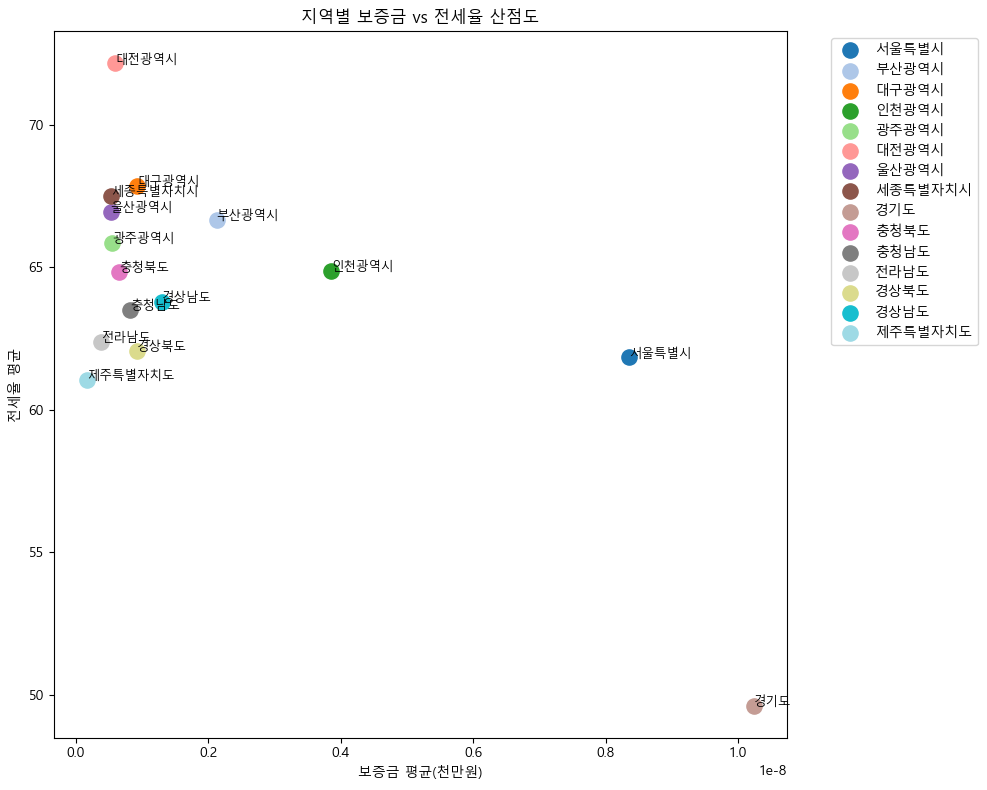

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# 컬럼 이름 지정
language_df.columns = ['region', '보증사고 건수 평균', '전세율 평균']

language_df['보증금 평균(천만원)'] = language_df['보증사고 건수 평균'] / 100000000000

plt.figure(figsize=(10,8))

colors = plt.cm.tab20(np.linspace(0, 1, len(language_df)))

for i, row in language_df.iterrows():
    plt.scatter(
        row['보증금 평균(천만원)'],
        row['전세율 평균'],
        color=colors[i],
        s=120,
        label=row['region']
    )

    # 지역 이름 표시 (선택)
    plt.text(
        row['보증금 평균(천만원)'],
        row['전세율 평균'],
        row['region'],
        fontsize=9
    )

plt.xlabel("보증금 평균(천만원)")
plt.ylabel("전세율 평균")
plt.title("지역별 보증금 vs 전세율 산점도")

# 👉 축 비율 강제 설정 없음 → 원 값 그대로
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()